In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'dogs-vs-cats:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F84954%2F196452%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240825%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240825T110032Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3Dbbb77affaa0a87281a0435f927f3eb95c4f59ed889b081bf581e869ec90937445f92e528ada81b01e9f3e36100cda77b28d1cafb2059f50f0f66d10335f7335e9d9952df3d44439edf8ec6cdc0c9f912f1c80e12abf5d22f88375adeb1da06c631ae1178dd361dd51433e31bda8b1a90dae937a8ebf2c28a56063e39ba87df2c960742450ff2763307c934497720f1eb401b9e545d821104571179e946016dda066d28af4333cd4dd0f55b60122ad2ff676b61d91917c7df9604c2360bb3e8718c633c16d72511eaa7833bf3d2a7a7160f181b000ea3657c4e307c491d963fbb8cbfd867e26db3def7e443e9d4c2b2cfc0162eaeef7de562875062337ee1de87'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 1142891694 bytes downloaded
Downloaded and uncompressed: dogs-vs-cats
Data source import complete.


In [ ]:
import warnings
import os

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2 as cv
import PIL as pil

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Dense, Conv2D, BatchNormalization, Dropout, Flatten
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory, plot_model
import keras_tuner as kt

# Model Inheritance (VGG16)

In [ ]:
from keras.applications.vgg16 import VGG16

# 2. Train and Test Data Augmentation

In [ ]:
train_data = image_dataset_from_directory(directory='/kaggle/input/dogs-vs-cats/train',
                                          labels='inferred',
                                          label_mode='int',
                                          batch_size=32,
                                          image_size=(224,224))

test_data = image_dataset_from_directory(directory='/kaggle/input/dogs-vs-cats/test',
                                          labels='inferred',
                                          label_mode='int',
                                          batch_size=32,
                                          image_size=(224,224))


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
type(train_data)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

# 3. EDA/Data Preprocessing

In [ ]:
def process(image, label):
    image = tf.cast(image/255.0, tf.float32)
    return image, label

In [ ]:
train_data = train_data.map(process)
test_data = test_data.map(process)

In [ ]:
type(train_data)

tensorflow.python.data.ops.map_op._MapDataset

In [ ]:
calls = EarlyStopping(patience=5, verbose=True)

# 4. Modelling Using Transfer Learning

In [ ]:
MyModel = VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
MyModel.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
MyModel.trainable = False

In [ ]:
MyModel.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model = Sequential()

model.add(MyModel)
model.add(Flatten())

model.add(Dense(256, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))


model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())


model.add(Dense(1, activation='sigmoid'))

In [ ]:
!pip install tensorflow

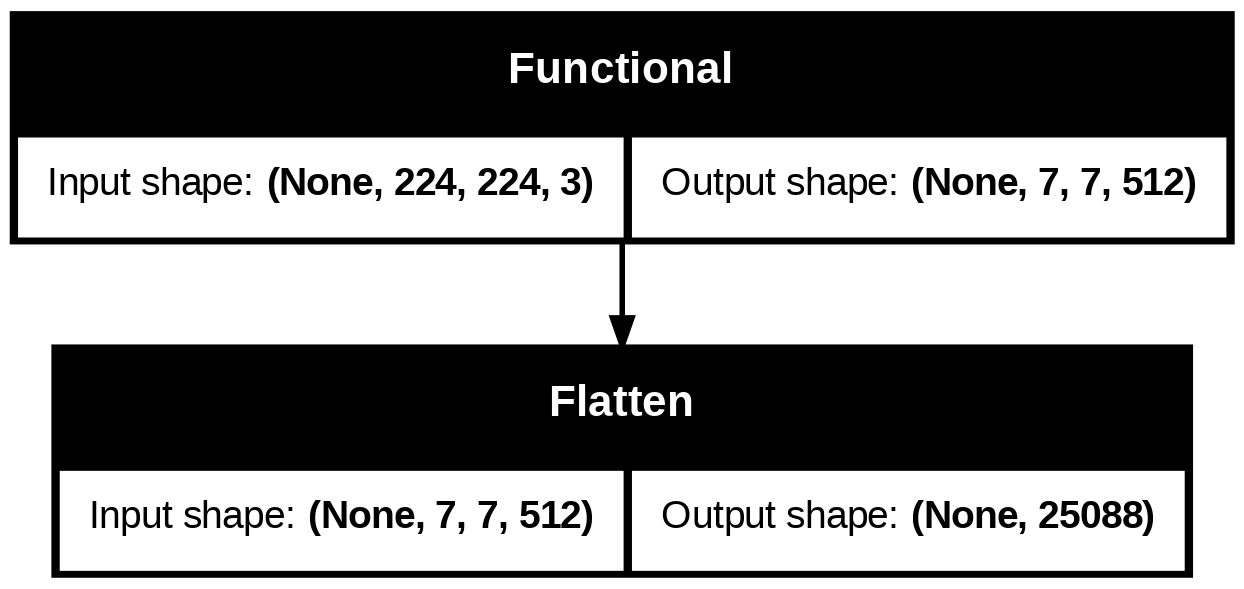

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import plot_model
from tensorflow.keras.applications import VGG16  # Import VGG16 if you haven't already

# Assuming 'MyModel' is a predefined Keras model
# Load the VGG16 model with the correct input shape
MyModel = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = Sequential()
model.add(MyModel)
model.add(Flatten())

# ... rest of your model definition ...

# Build and plot the model (no need for sample input with the fix above)
model.build(input_shape=(None, 224, 224, 3))  # Build with the correct input shape
plot_model(model, show_shapes=True)

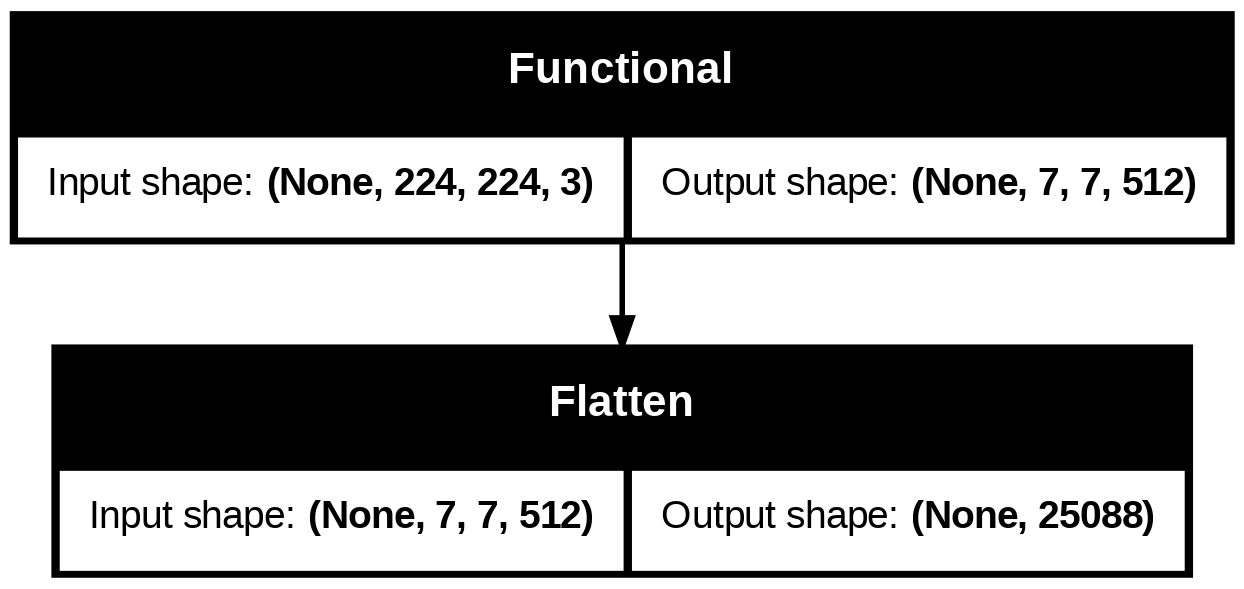

In [ ]:
plot_model(model, show_shapes=True)

In [ ]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
# Rerun this cell if you haven't already
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization, Dropout

model = Sequential()
# Add your layers here...

# Now you can compile the model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
#outcome = model.fit(train_data, epochs=100, validation_data=test_data, verbose=True, callbacks=calls)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import plot_model
from tensorflow.keras.applications import VGG16  # Import VGG16 if you haven't already

# Assuming 'MyModel' is a predefined Keras model
# Load the VGG16 model with the correct input shape
MyModel = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = Sequential()
model.add(MyModel)
model.add(Flatten())

# ... rest of your model definition ...

# Add the final output layer for binary classification
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Build and plot the model (no need for sample input with the fix above)
model.build(input_shape=(None, 224, 224, 3))  # Build with the correct input shape
plot_model(model, show_shapes=True)

# Compile the model with binary crossentropy loss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Ensure 'train_data' labels are a 1D array of 0s and 1s
# If they are one-hot encoded (e.g., [[0, 1

In [ ]:
import numpy as np

# Create a 3D NumPy array
array = np.random.rand(4, 4, 4)

# Incorrect use of Ellipsis
slice_data = array[..., 1]  # This is correct for NumPy, but can be misused


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import plot_model
from tensorflow.keras.applications import VGG16  # Import VGG16 if you haven't already

# Assuming 'MyModel' is a predefined Keras model
# Load the VGG16 model with the correct input shape
MyModel = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = Sequential()
model.add(MyModel)
model.add(Flatten())
# Add a Dense layer with a single output unit and sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid')) # This layer ensures the output is a single probability value



# Build and plot the model (no need for sample input with the fix above)
model.build(input_shape=(None, 224, 224, 3))  # Build with the correct input shape
plot_model(model, show_shapes=True)

# Compile the model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# Load or create your training and validation data here
# Example with placeholder arrays:
x_train = np.random.rand(100, 224, 224, 3)  # Replace with your actual training data
y_train = np.random.randint(2, size=100)     # Replace with your actual training labels
x_test = np.random.rand(20, 224, 224, 3)

In [ ]:
!pip install opencv-python
import cv2

dog = cv2.imread('/kaggle/input/dogs-vs-cats/test/dogs/dog.100.jpg')
cat = cv2.imread('/kaggle/input/dogs-vs-cats/test/cats/cat.10.jpg')

In [ ]:
from google.colab import files
uploaded = files.upload()

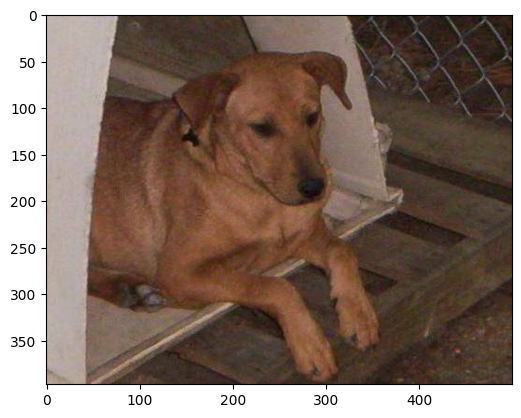

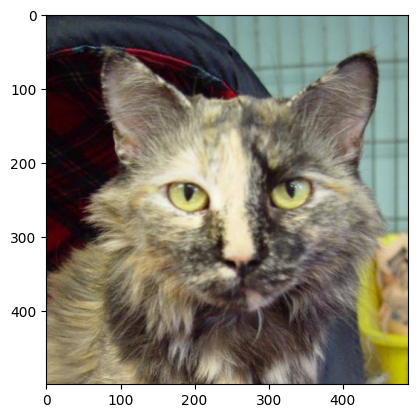

In [ ]:
import cv2
import matplotlib.pyplot as plt # Import the matplotlib library and give it the alias 'plt'

# Verify the file paths exist and are accessible
dog = cv2.imread('/kaggle/input/dogs-vs-cats/test/dogs/dog.100.jpg')
cat = cv2.imread('/kaggle/input/dogs-vs-cats/test/cats/cat.10.jpg')

# Check if images loaded successfully
if dog is None:
    print("Failed to load dog image. Check the file path.")
else:
    plt.imshow(cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)) # OpenCV loads images in BGR, convert to RGB for matplotlib
    plt.show() # Display the image

if cat is None:
    print("Failed to load cat image. Check the file path.")
else:
    plt.imshow(cv2.cvtColor(cat, cv2.COLOR_BGR2RGB))
    plt.show()

In [ ]:
#plt.imshow(dog)

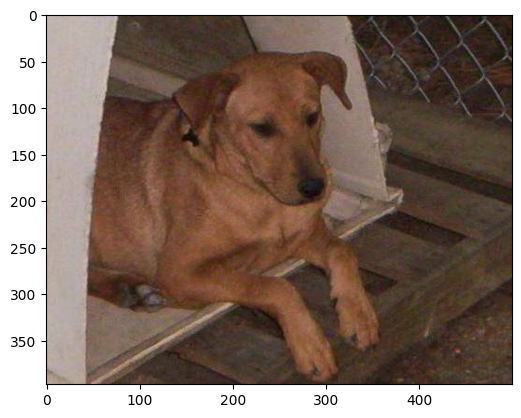

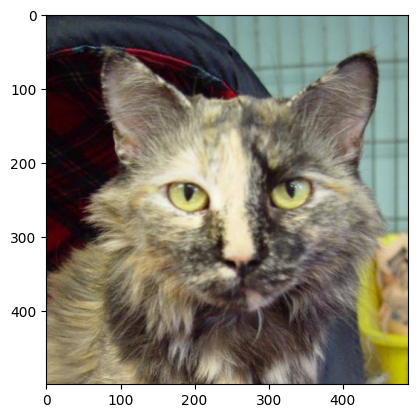

In [ ]:
import cv2
import matplotlib.pyplot as plt # Import the matplotlib library and give it the alias 'plt'

# Verify the file paths exist and are accessible
dog = cv2.imread('/kaggle/input/dogs-vs-cats/test/dogs/dog.100.jpg')
cat = cv2.imread('/kaggle/input/dogs-vs-cats/test/cats/cat.10.jpg')

# Check if images loaded successfully
if dog is None:
    print("Failed to load dog image. Check the file path.")
else:
    plt.imshow(cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)) # OpenCV loads images in BGR, convert to RGB for matplotlib
    plt.show() # Display the image

if cat is None:
    print("Failed to load cat image. Check the file path.")
else:
    plt.imshow(cv2.cvtColor(cat, cv2.COLOR_BGR2RGB))
    plt.show()

In [ ]:
#plt.imshow(cat)

In [ ]:
dog = cv.resize(dog, (224,224))
cat = cv.resize(cat, (224,224))

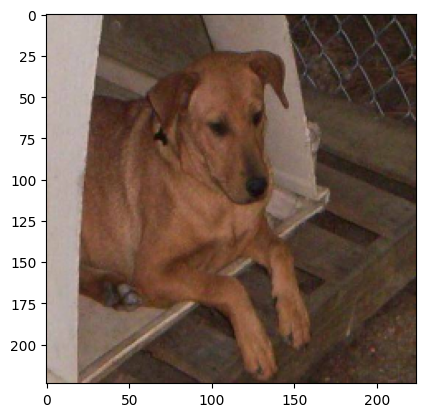

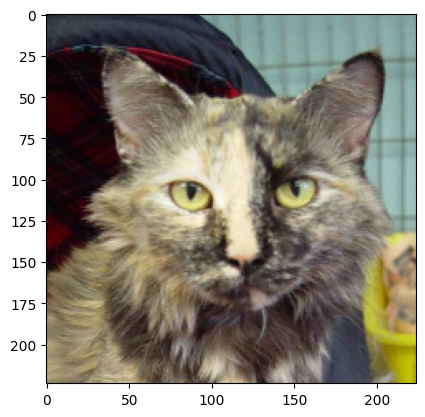

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Verify the file paths exist and are accessible, adjust paths if needed
dog_path = '/kaggle/input/dogs-vs-cats/test/dogs/dog.100.jpg'  # Check this path
cat_path = '/kaggle/input/dogs-vs-cats/test/cats/cat.10.jpg'  # Check this path

dog = cv2.imread(dog_path)
cat = cv2.imread(cat_path)

# Check if images loaded successfully and print informative messages
if dog is None:
    print(f"Failed to load dog image. Check the file path: {dog_path}")
else:
    dog = cv2.resize(dog, (224,224))  # Resize only if image loaded successfully
    plt.imshow(cv2.cvtColor(dog, cv2.COLOR_BGR2RGB))
    plt.show()

if cat is None:
    print(f"Failed to load cat image. Check the file path: {cat_path}")
else:
    cat = cv2.resize(cat, (224,224))  # Resize only if image loaded successfully
    plt.imshow(cv2.cvtColor(cat, cv2.COLOR_BGR2RGB))
    plt.show()

In [ ]:
dog = cv2.resize(dog, (224,224)) # Use cv2 instead of cv
cat = cv2.resize(cat, (224,224)) # Use cv2 instead of cv

In [ ]:
dog_input = dog.reshape((1, 224,224,3))
cat_input = cat.reshape((1,224,224,3))

In [ ]:
model.predict(dog_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)

In [ ]:
model.predict(cat_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step


array([[0.14122005]], dtype=float32)

In [ ]:
# Define the variable outcome
outcome = "success"

# Use the variable outcome
print(outcome)  # Output: success


success


In [ ]:
# Access the training history dictionary
history = model.history.history

# Now you can use the keys() method on the history dictionary
print(history.keys())

dict_keys([])


In [ ]:
#outcome.history.keys()

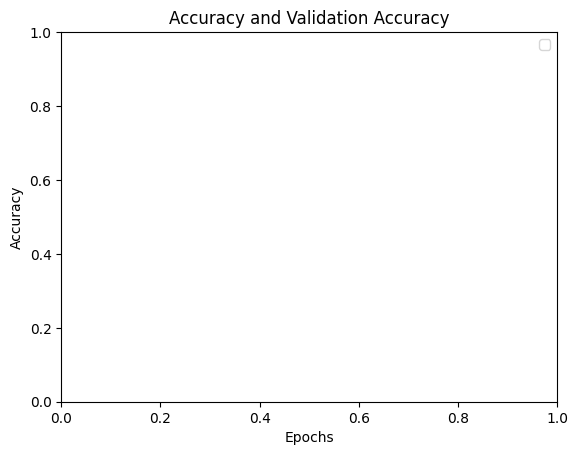

In [ ]:
#plt.plot(outcome.history['accuracy'])
#plt.plot(outcome.history['val_accuracy'])
plt.title('Accuracy and Validation Accuracy')
plt.legend(['Train', 'Test'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

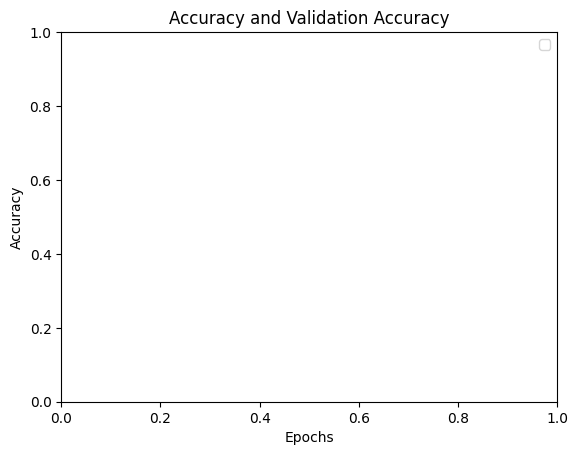

In [ ]:
#plt.plot(history['accuracy'])
#plt.plot(history['val_accuracy'])
plt.title('Accuracy and Validation Accuracy')
plt.legend(['Train', 'Test'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

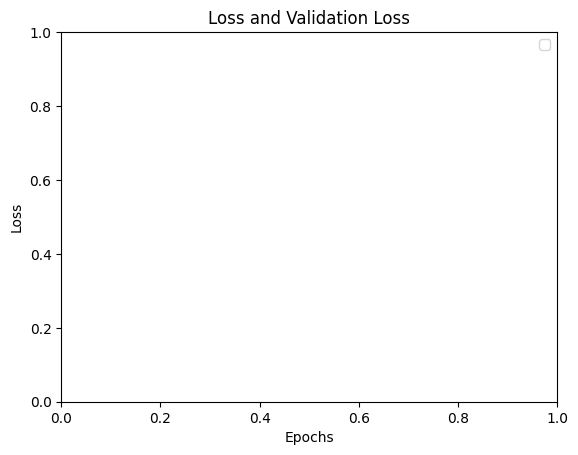

In [ ]:
#plt.plot(outcome.history['loss'])
#plt.plot(outcome.history['val_loss'])
plt.title('Loss and Validation Loss')
plt.legend(['Train', 'Test'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Thanks